In [1]:
class Dog:
    species = "Canis familiaris"

    def __init__(self, name, age):
        self.name = name
        self.age = age

miles = Dog("Miles", 4)
buddy = Dog("Buddy", 9)

print(miles.species)  # 
print(buddy.name)
print(Dog.species)

Canis familiaris
Buddy
Canis familiaris


출력 예측
Canis familiaris , Buddy, Canis familiaris
species는 class 변수여서. 모든 객체가 공유한다.

In [2]:
class Dog:
    def __init__(self, name, age):
        self.name = name
        self.age = age

d = Dog()

TypeError: Dog.__init__() missing 2 required positional arguments: 'name' and 'age'

어떤 에러? 
초기화 변수들이 들어가지 않아서

In [3]:
class Dog:
    def __init__(self, name="", age=0):
        self.name = name
        self.age = age

d = Dog()

이렇게 바꿔야됨.

Q3. 빈칸 채우기
Car 클래스를 완성하세요. color(문자열)와 mileage(정수)를 instance attribute로 갖고, print(car)를 하면 The blue car has 20,000 miles처럼 출력되게 합니다.

In [4]:
class Car():
    def __init__(self,color,mileage):
        self.color = color
        self.mileage = mileage

    def __str__(self):
        return f"The {self.color} car has {self.mileage:,} miles"

blue_car = Car("blue",20000)
print(blue_car)

The blue car has 20,000 miles


In [5]:
# 출력 예측
class Counter:
    count = 0

    def __init__(self):
        self.count = self.count + 1

a = Counter()
b = Counter()
print(a.count, b.count, Counter.count)

1 1 0


In [6]:
# 출력 예측
class Counter:
    count = 0

    def __init__(self):
        Counter.count = Counter.count + 1

a = Counter()
b = Counter()
print(a.count, b.count, Counter.count)

2 2 2


Q5. 버그 찾기 + PyTorch 연결

```python
class MyLinear:
    def __init__(self, in_features, out_features):
        in_features = in_features
        out_features = out_features

    def describe(self):
        return f"in={self.in_features}, out={self.out_features}"

layer = MyLinear(3, 4)
print(layer.describe())
```

In [7]:
class MyLinear:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features

    def describe(self):
        return f"in={self.in_features}, out={self.out_features}"

layer = MyLinear(3, 4)
print(layer.describe())

in=3, out=4


요구사항: 아래 조건을 만족하는 MyLinear 클래스를 처음부터 작성하세요.

in_features, out_features를 받아 instance attribute로 저장한다.
weight라는 instance attribute를 만든다. 값은 [[0.0] * in_features for _ in range(out_features)] (리스트의 리스트)로 초기화한다.
print(layer)를 하면 MyLinear(in_features=3, out_features=4)가 출력된다.
클래스 attribute로 layer_count = 0을 두고, 인스턴스가 만들어질 때마다 클래스 전체의 카운트가 1씩 증가하게 한다. (Q4에서 배운 걸 그대로 적용해보세요.)

In [8]:
class MyLinear():
    layer_count = 0

    def __init__(self, a, b):
        self.in_features = a
        self.out_features = b
        self.weight = [[0.0] * self.in_features for _ in range(self.out_features)]
        MyLinear.layer_count += 1

    def __str__(self):
        return f"MyLinear(in_features= {self.in_features}, out_features= {self.out_features})"


a = MyLinear(3, 4)
b = MyLinear(5, 2)
print(a)                    # MyLinear(in_features=3, out_features=4)
print(MyLinear.layer_count) # 2
print(len(a.weight), len(a.weight[0]))  # 4 3


MyLinear(in_features= 3, out_features= 4)
2
4 3


Step 2 퀴즈: Dunder Methods (5문제)

범위는 __call__, __len__, __getitem__, __repr__ vs __str__이에요. 문제를 먼저 다 풀고, 아래 풀이로 확인하세요. 설명이 요구된 문제는 설명까지 써주세요.

Q1. 출력 예측 (__call__)

```python
class Doubler:
    def __init__(self):
        self.calls = 0

    def __call__(self, x):
        self.calls += 1
        return x * 2

d = Doubler()
print(d(3))
print(d(10))
print(d.calls)
print(callable(d), callable(Doubler), callable(d.calls))
```
(a) 4줄의 출력을 쓰세요.
(b) d(3)이라고 쓰면 Python이 실제로 어떤 메서드를 호출하는지 한 문장으로 설명하세요.

(a)
6
20
2
(b)
True True False

---
PyTorch 연결: model(x), layer(x), loss_fn(pred, y)가 전부 이 원리예요. 또 Doubler처럼 호출 사이에 상태(self.calls)를 유지할 수 있다는 게 단순 함수와 다른 점이고, nn.Module이 파라미터를 들고 다니면서 model(x)로 호출되는 이유예요.

Q2. 에러 찾기 (__len__, __getitem__)
```python
class MyDataset:
    def __init__(self, data):
        self.data = data

ds = MyDataset([10, 20, 30])
print(len(ds))
print(ds[1])


(a) 각 줄에서 나는 에러 이름과 메시지 패턴을 쓰세요.
(b) 두 줄이 모두 동작하도록 클래스에 메서드를 추가하세요.
(c) 메서드를 추가한 뒤 for x in ds: print(x)가 동작하는지 예측하고, 동작한다면 왜 그런지 설명하세요. (힌트: __iter__를 정의하지 않았습니다.)
```


In [13]:
class MyDataset:
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

ds = MyDataset([10, 20, 30])
print(len(ds))
print(ds[1])
for x in ds: print(x)

3
20
10
20
30


Q4. 빈칸 채우기 (__call__ + forward 구조)

PyTorch의 nn.Module이 하는 일을 흉내 낸 코드예요. 빈칸을 채우고, 마지막 질문에 답하세요.

```python
class MyModule:
    def ____(self, *args):
        return self.forward(*args)

    def forward(self, x):
        raise NotImplementedError

class Square(MyModule):
    def ____(self, x):
        return x ** 2

model = Square()
print(model(4))          # 16
print(model.forward(4))  # 16

(a) 빈칸 2개를 채우세요.
(b) model(4)와 model.forward(4)는 결과가 같지만, PyTorch에서는 model(x)로 호출하는 것이 권장돼요. forward를 직접 호출하면 어떤 점이 문제일지 추측해서 써보세요. (힌트: 지금 MyModule.__call__은 forward만 호출하지만, 진짜 nn.Module.__call__은 그 앞뒤로 뭔가 더 합니다.)
```

---

**(b) `forward(x)`를 직접 호출하면 왜 문제인가:**

지금 이 간단한 예제의 `__call__`은 그냥 `forward`를 호출만 하지만, 실제 PyTorch의 `nn.Module.__call__`은 그 앞뒤로 훨씬 많은 일을 합니다. 예를 들어:

- **forward hook / backward hook 실행** — `register_forward_hook`으로 등록해둔 함수들을 `forward` 실행 전후로 자동 실행
- **autograd 연산 그래프 연결** — 역전파(backpropagation)를 위한 계산 그래프를 제대로 구성
- **training/eval 모드 처리** — `model.train()` / `model.eval()` 상태에 따라 Dropout, BatchNorm 같은 레이어가 다르게 동작하도록 처리
- 기타 내부 상태 관리 (예: 파라미터 추적 등)

그래서 `model.forward(x)`처럼 직접 호출하면, 이런 부가 작업들을 전부 건너뛰게 됩니다. 결과값(숫자)은 우연히 같을 수 있지만, **hook이 실행 안 되거나, gradient 계산에 문제가 생기거나, train/eval 모드가 제대로 반영 안 되는** 등의 버그로 이어질 수 있어요.

**한 문장 요약**: `model(x)`는 "정식 절차(hook, 모드 처리, 그래프 연결 등)를 전부 거쳐서" `forward`를 실행하지만, `model.forward(x)`는 그 절차들을 다 생략하고 계산만 하는 것이라, 겉보기엔 같아 보여도 위험합니다.



In [ ]:
class MyModule:
    def __call__(self, *args):
        return self.forward(*args)

    def forward(self, x):
        raise NotImplementedError

class Square(MyModule):
    def forward(self, x):
        return x ** 2

model = Square()
print(model(4))          # 16
print(model.forward(4))  # 16


16
16


### Q5. Scratch: `MyDataset` 작성

아래 요구사항만 보고 **처음부터** 작성하세요.

1. `data`(리스트)와 `labels`(리스트)를 받아 instance attribute로 저장한다.
2. `len(ds)`가 샘플 개수를 반환한다.
3. `ds[i]`가 `(data[i], labels[i])` 튜플을 반환한다.
4. `print(ds)`를 하면 `MyDataset(size=3)`처럼 출력된다. (샘플 개수가 3일 때. **`=` 앞뒤에 공백 없음**에 주의하세요.)

검증 코드:

python

```python
ds = MyDataset([10, 20, 30], ["a", "b", "c"])print(len(ds))    # 3print(ds[1])      # (20, 'b')print(ds)         # MyDataset(size=3)for x, y in ds:    print(x, y)
```

작성 후 **마지막 `for` 루프가 왜 동작하는지 한 줄** 덧붙여주세요. (Q2 (c)와 같은 원리예요.)

In [26]:
class MyDataset():
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, key):
        return (self.data[key], self.labels[key])

    def __str__(self):
        return f"MyDataset(size={len(self)})"

ds = MyDataset([10, 20, 30], ["a", "b", "c"])
print(len(ds))    # 3
print(ds[1])      # (20, 'b')
print(ds)         # MyDataset(size=3)
for x, y in ds:
    print(x, y)

3
(20, 'b')
MyDataset(size=3)
10 a
20 b
30 c


Step 3 퀴즈: 상속과 super().__init__() (5문제)

범위는 상속 기본, method override, super(), isinstance(), 그리고 super().__init__()을 빼먹으면 생기는 문제예요. 문제 전체를 먼저 풀고, 아래 풀이로 확인하세요. 설명이 요구된 문제는 설명까지 써주세요.

Q1. 출력 예측 (상속 + override)
```python
class Animal:
    kind = "animal"

    def __init__(self, name):
        self.name = name

    def speak(self):
        return f"{self.name} makes a sound"

class Dog(Animal):
    def speak(self):
        return f"{self.name} says Woof"

class Cat(Animal):
    kind = "cat"

a = Animal("Generic")
d = Dog("Miles")
c = Cat("Tom")

print(a.speak())
print(d.speak())
print(c.speak())
print(a.kind, d.kind, c.kind)
print(isinstance(d, Animal), isinstance(d, Cat), isinstance(a, Dog))

(a) 5줄의 출력을 쓰세요.
(b) Dog에는 __init__이 없는데 Dog("Miles")가 왜 에러 없이 동작하는지 한 문장으로 설명하세요.
```
---



In [36]:
class Animal:
    kind = "animal"

    def __init__(self, name):
        self.name = name

    def speak(self):
        return f"{self.name} makes a sound"

class Dog(Animal):
    def speak(self):
        return f"{self.name} says Woof"

class Cat(Animal):
    kind = "cat"

a = Animal("Generic")
d = Dog("Miles")
c = Cat("Tom")

print(a.speak())
print(d.speak())
print(c.speak())
print(a.kind, d.kind, c.kind)
print(isinstance(d, Animal), isinstance(d, Cat), isinstance(a, Dog))
print('"속성을 찾을 때 자기 것이 없으면 부모 것을 빌려쓴다"는 규칙이 메소드(__init__도 결국 메소드)에도 똑같이 적용')

Generic makes a sound
Miles says Woof
Tom makes a sound
animal animal cat
True False False
"속성을 찾을 때 자기 것이 없으면 부모 것을 빌려쓴다"는 규칙이 메소드(__init__도 결국 메소드)에도 똑같이 적용


- **클래스 변수**: 그 클래스로 만든 **모든 인스턴스가 공유**하는 하나의 값. 클래스 몸체에 바로 적음 (`self.` 없이)
- **인스턴스 변수**: **각 인스턴스마다 따로** 가지는 값. `self.`를 붙여서 만듦 (보통 `__init__` 안에서)

PyTorch 연결: nn.Module도 마찬가지로, 레이어들(self.linear = nn.Linear(...) 등)을 항상 __init__ 안에서 정의합니다. 그래야 모델을 만드는 순간 모든 파라미터가 확실하게 등록되기 때문이에요.

출력 예측
Canis familiaris , Buddy, Canis familiaris
species는 class 변수여서. 모든 객체가 공유한다.

In [ ]:
class Dog:
    def __init__(self, name, age):
        self.name = name
        self.age = age

d = Dog()

TypeError: Dog.__init__() missing 2 required positional arguments: 'name' and 'age'

어떤 에러? 
초기화 변수들이 들어가지 않아서

In [ ]:
class Dog:
    def __init__(self, name="", age=0):
        self.name = name
        self.age = age

d = Dog()

이렇게 바꿔야됨.

Q3. 빈칸 채우기
Car 클래스를 완성하세요. color(문자열)와 mileage(정수)를 instance attribute로 갖고, print(car)를 하면 The blue car has 20,000 miles처럼 출력되게 합니다.

In [ ]:
class Car():
    def __init__(self,color,mileage):
        self.color = color
        self.mileage = mileage

    def __str__(self):
        return f"The {self.color} car has {self.mileage:,} miles"

blue_car = Car("blue",20000)
print(blue_car)

The blue car has 20,000 miles


In [ ]:
# 출력 예측
class Counter:
    count = 0

    def __init__(self):
        self.count = self.count + 1

a = Counter()
b = Counter()
print(a.count, b.count, Counter.count)

1 1 0


In [ ]:
# 출력 예측
class Counter:
    count = 0

    def __init__(self):
        Counter.count = Counter.count + 1

a = Counter()
b = Counter()
print(a.count, b.count, Counter.count)

2 2 2


Q5. 버그 찾기 + PyTorch 연결

```python
class MyLinear:
    def __init__(self, in_features, out_features):
        in_features = in_features
        out_features = out_features

    def describe(self):
        return f"in={self.in_features}, out={self.out_features}"

layer = MyLinear(3, 4)
print(layer.describe())
```

In [ ]:
class MyLinear:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features

    def describe(self):
        return f"in={self.in_features}, out={self.out_features}"

layer = MyLinear(3, 4)
print(layer.describe())

in=3, out=4


요구사항: 아래 조건을 만족하는 MyLinear 클래스를 처음부터 작성하세요.

in_features, out_features를 받아 instance attribute로 저장한다.
weight라는 instance attribute를 만든다. 값은 [[0.0] * in_features for _ in range(out_features)] (리스트의 리스트)로 초기화한다.
print(layer)를 하면 MyLinear(in_features=3, out_features=4)가 출력된다.
클래스 attribute로 layer_count = 0을 두고, 인스턴스가 만들어질 때마다 클래스 전체의 카운트가 1씩 증가하게 한다. (Q4에서 배운 걸 그대로 적용해보세요.)

In [ ]:
class MyLinear():
    layer_count = 0

    def __init__(self, a, b):
        self.in_features = a
        self.out_features = b
        self.weight = [[0.0] * self.in_features for _ in range(self.out_features)]
        MyLinear.layer_count += 1

    def __str__(self):
        return f"MyLinear(in_features= {self.in_features}, out_features= {self.out_features})"


a = MyLinear(3, 4)
b = MyLinear(5, 2)
print(a)                    # MyLinear(in_features=3, out_features=4)
print(MyLinear.layer_count) # 2
print(len(a.weight), len(a.weight[0]))  # 4 3


MyLinear(in_features= 3, out_features= 4)
2
4 3


### Q2. 에러 찾기 (`super().__init__()` 누락)

python

```python
class Parent:
    def __init__(self, name):
        self.name = name

class Child(Parent):
    def __init__(self, name, age):
        self.age = age

c = Child("Miles", 4)
print(c.age)
print(c.name)
```

(a) 어느 줄에서 어떤 에러가 나는지 쓰세요. (에러 이름과 메시지 패턴 포함)

(b) 고친 `Child` 클래스를 쓰세요.

(c) PyTorch의 `nn.Module`을 상속한 클래스에서 `super().__init__()`을 빼먹으면, 이 문제와 **같은 원리**로 어떤 일이 벌어질지 추측해서 써보세요. (힌트: `nn.Module.__init__`도 `self.____ = ...` 형태로 무언가를 만들어두는 초기화 코드입니다.)

In [45]:
class Parent:
    def __init__(self, name):
        self.name = name

class Child(Parent):
    def __init__(self, name, age):
        super().__init__(name)
        self.age = age

c = Child("Miles", 4)
print(c.age)
print(c.name)

4
Miles


Q3. 출력 예측 (super()와 호출 순서)
```python
class Base:
    def __init__(self):
        print("Base init")
        self.x = 1

    def show(self):
        return f"Base show: x={self.x}"

class Mid(Base):
    def __init__(self):
        print("Mid init start")
        super().__init__()
        self.y = 2
        print("Mid init end")

    def show(self):
        return super().show() + f", y={self.y}"

m = Mid()
print(m.show())

(a) 출력 전체를 순서대로 쓰세요.
(b) Mid.show()에서 super().show()를 빼고 return f"Mid show: y={self.y}"로 바꾸면 출력이 어떻게 달라지는지 쓰세요.

```
---

Mid init start
Base init
Base show: x=1
Mid init end
Base show: x=1, y=2

Q4. 빈칸 채우기 (nn.Module 패턴)

PyTorch 없이 nn.Module의 구조를 흉내 낸 코드예요. 빈칸을 채우세요.

```python
class MyModule:
    def __init__(self):
        self.training = True

    def __call__(self, *args):
        return self.forward(*args)

    def forward(self, *args):
        raise NotImplementedError

class MyLinear(____):
    def __init__(self, in_features, out_features):
        ____.__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = [[0.0] * in_features for _ in range(out_features)]

    def ____(self, x):
        return [sum(w * xi for w, xi in zip(row, x)) for row in self.weight]

layer = MyLinear(3, 2)
print(layer.training)              # True
print(layer([1.0, 2.0, 3.0]))     # [0.0, 0.0]

(a) 빈칸 3개를 채우세요.
(b) layer.training이 True로 나오는 것은 MyLinear가 training을 직접 만들지 않았는데도 가능해요. 이 값이 어느 클래스의 어느 메서드에서 만들어졌는지 쓰세요.
(c) 이 코드에서 MyLinear.forward가 MyModule.forward를 override하는 것이 왜 필요한지 한 문장으로 쓰세요.

```

MyModule의 forward는 빈껍데기.
MyLinear에서 MyModule의 forward를 오버라이딩(덮어쓰기)해줘야 한다.

In [ ]:
class MyModule:
    def __init__(self):
        self.training = True

    def __call__(self, *args):
        return self.forward(*args)

    def forward(self, *args):
        raise NotImplementedError

class MyLinear(MyModule):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = [[0.0] * in_features for _ in range(out_features)]

    def forward(self, x):
        return [sum(w * xi for w, xi in zip(row, x)) for row in self.weight]

layer = MyLinear(3, 2)
print(layer.training)              # True
print(layer([1.0, 2.0, 3.0]))     # [0.0, 0.0]

Mid init start
Base init
Mid init end
Base show: x=1, y=2


"자식 클래스가 특정 메소드를 오버라이딩하지 않았다면, 부모 클래스의 것을 그대로 물려받아 쓴다."

### Q5. Scratch: `MyModel` 작성

Q4의 `MyModule`과 `MyLinear`가 이미 있다고 가정하고, 아래 요구사항만 보고 **처음부터** 작성하세요.

1. `MyModule`을 상속하는 `MyModel` 클래스를 만든다.
2. `__init__(self, in_features, hidden, out_features)`에서 `super().__init__()`을 호출한다.
3. `self.fc1 = MyLinear(in_features, hidden)`, `self.fc2 = MyLinear(hidden, out_features)`를 만든다.
4. `forward(self, x)`는 `self.fc2(self.fc1(x))`를 반환한다.
5. `print(model)`을 하면 `MyModel(fc1=3->4, fc2=4->2)`처럼 출력된다. (`in_features=3, hidden=4, out_features=2`일 때. **`>` 앞뒤 공백 없음, `=` 앞뒤 공백 없음**에 주의하세요.)

검증 코드:

python

```python
model = MyModel(3, 4, 2)
print(model([1.0, 2.0, 3.0]))   # [0.0, 0.0]
print(model)                    # MyModel(fc1=3->4, fc2=4->2)
print(model.training)           # True
print(isinstance(model, MyModule))  # True
```

작성 후 **`model(x)` 한 줄이 실행될 때 `__call__`과 `forward`가 어떤 순서로 몇 번 불리는지** 한 줄로 덧붙여주세요. (`fc1`, `fc2` 호출까지 포함해서 생각해보세요.)

In [50]:
class MyModule:
    def __init__(self):
        self.training = True

    def __call__(self, *args):
        return self.forward(*args)

    def forward(self, *args):
        raise NotImplementedError

class MyLinear(MyModule):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = [[0.0] * in_features for _ in range(out_features)]

    def forward(self, x):
        return [sum(w * xi for w, xi in zip(row, x)) for row in self.weight]


class MyModel(MyModule):
    def __init__(self, in_features, hidden, out_features):
        super().__init__()
        self.fc1 = MyLinear(in_features, hidden)
        self.fc2 = MyLinear(hidden, out_features)

    def forward(self, x):
        return self.fc2(self.fc1(x))

    def __str__(self):
        return f"MyModel(fc1={self.fc1.in_features}->{self.fc1.out_features}, fc2={self.fc2.in_features}->{self.fc2.out_features})"


model = MyModel(3, 4, 2)
print(model([1.0, 2.0, 3.0]))   # [0.0, 0.0]
print(model)                    # MyModel(fc1=3->4, fc2=4->2)
print(model.training)           # True
print(isinstance(model, MyModule))  # True

[0.0, 0.0]
MyModel(fc1=3->4, fc2=4->2)
True
True


## 헷갈림의 정체: "상속"과 "포함"은 다른 관계다

```python
class MyLinear(MyModule):    # ← 이건 "상속" (is-a, ~이다)
class MyModel(MyModule):     # ← 이것도 "상속" (is-a, ~이다)

class MyModel(MyModule):
    def __init__(self, ...):
        self.fc1 = MyLinear(...)   # ← 이건 "포함/구성" (has-a, ~을 가지고 있다)
        self.fc2 = MyLinear(...)
```

**상속 (is-a)**: "`MyLinear`는 `MyModule`의 한 종류**이다**" → 화살표는 **클래스와 클래스 사이포함 (has-a)**: "`MyModel`은 `MyLinear` 인스턴스를 속성으로 **가지고 있다**" → 화살표는 **인스턴스와 인스턴스 사이** (변수 저장일 뿐)

## 그림으로 완전히 분리해서 보기

```
[상속 관계 - 클래스 설계도끼리]
        MyModule
       /        \
   MyLinear    MyModel
   (레고 블록)   (레고 블록)

[포함 관계 - 실제 만들어진 객체끼리]
   model (MyModel 인스턴스)
     ├── self.fc1 → MyLinear 인스턴스
     └── self.fc2 → MyLinear 인스턴스
```

**핵심 통찰**: `MyLinear`와 `MyModel`은 "형제"입니다. 둘 다 똑같이 `MyModule`이라는 부모에게서 `__call__`, `training` 같은 공통 기능을 물려받아요. 그리고 `MyModel`은 그 형제인 `MyLinear`를 **재료로 사용**해서 자기 안에 두 개 박아넣은 것뿐입니다. 상속 트리는 위아래(부모-자식)로만 보고, 포함 관계는 "이 객체 안에 저 객체가 변수로 들어있다"는 별개의 그림으로 보세요.

## `forward`가 두 군데 있어서 헷갈리는 것도 같은 원리로 풀림

**규칙: `forward`는 "이 레벨에서 내가 할 계산"만 정의한다. 각 클래스는 자기 레벨만 신경 쓴다.**

```python
class MyLinear(MyModule):
    def forward(self, x):
        # "선형변환 하나"를 어떻게 계산하는지만 앎
        return [...]

class MyModel(MyModule):
    def forward(self, x):
        # "fc1 결과를 fc2에 넣는다"는 것만 앎
        # fc1, fc2 내부가 어떻게 계산되는지는 전혀 몰라도 됨!
        return self.fc2(self.fc1(x))
```

`model([1.0, 2.0, 3.0])`을 실행하면 실제로 이렇게 이어집니다 (호출 체인):

```
model(x)
 └─ MyModule.__call__ (상속받음) → self.forward(x) 호출
     └─ MyModel.forward(x) 실행
         └─ self.fc1(x) 호출
             └─ MyModule.__call__ (fc1이 상속받음) → self.forward(x)
                 └─ MyLinear.forward(x) 실행 → 결과 반환
         └─ 그 결과를 self.fc2(...)에 넣음 → 같은 과정 반복
```

**절대 규칙**: `self.fc1(x)`라고 쓰면, `fc1`이 어떤 클래스든 상관없이 **그 객체 자신의 `forward`**가 실행됩니다. `MyModel.forward`는 `fc1.forward`가 내부적으로 뭘 하는지 전혀 몰라도 되고, 신경 쓸 필요도 없어요. **"각 레이어는 블랙박스처럼 자기 계산만 책임진다"**가 핵심입니다.

## 안 헷갈리는 3단계 읽는 순서 (암기용)

새 PyTorch 모델 코드를 볼 때마다 이 순서로 읽으세요:

1. **`class X(nn.Module):`** → "아, X는 nn.Module 계열이구나 (공통 기능 상속)" 하고 넘어감
2. **`__init__` 안의 `self.xxx = ...`** → "이 모델은 xxx라는 부품(레이어)들을 가지고 있구나" (조립도)
3. **`forward`** → "input이 들어오면 그 부품들을 어떤 순서로 거쳐가는지"만 확인 (실행 흐름도)

## 실전 PyTorch에 그대로 대응

```python
class MyModel(nn.Module):          # 1. nn.Module 상속 (공통 기능: __call__, .to(), .parameters() 등)
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 4)   # 2. 부품 조립 (nn.Linear도 nn.Module의 형제)
        self.fc2 = nn.Linear(4, 2)

    def forward(self, x):            # 3. 실행 흐름
        x = self.fc1(x)
        x = self.fc2(x)
        return x
```

`nn.Linear`도 우리 예제의 `MyLinear`와 똑같은 위치예요 — `nn.Module`을 상속받은 "부품"이고, 우리가 만드는 `MyModel`도 똑같이 `nn.Module`을 상속받은 "더 큰 부품"입니다. **레고처럼, 작은 블록(`nn.Linear`)들을 조립해서 큰 블록(`MyModel`)을 만드는 거고, 큰 블록도 결국 같은 규격(`nn.Module`)을 따르기 때문에 또 다른 모델 안에 부품으로 재사용될 수 있는 것**입니다.

Q1. 출력 예측 (@property)
```python
class Rectangle:
    def __init__(self, w, h):
        self.w = w
        self.h = h

    @property
    def area(self):
        return self.w * self.h

r = Rectangle(3, 4)
print(r.area)
r.w = 10
print(r.area)
print(r.area())

(a) 세 줄이 각각 어떻게 되는지 쓰세요. (출력 또는 에러 이름)
(b) area를 @property 없이 일반 메서드로 만들었다면, 첫 번째 print(r.area)의 출력은 어떻게 달라질까요?
```

In [52]:
class Rectangle:
    def __init__(self, w, h):
        self.w = w
        self.h = h

    @property
    def area(self):
        return self.w * self.h

r = Rectangle(3, 4)
print(r.area)
r.w = 10
print(r.area)
#print(r.area())

12
40


Q2. 빈칸 채우기 (@classmethod)

Point.from_tuple((1, 2))로 Point(1, 2)와 같은 객체를 만들 수 있도록 빈칸을 채우세요.

```python
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    ____
    def from_tuple(____, t):
        return ____(t[0], t[1])

p = Point.from_tuple((1, 2))
print(p.x, p.y)    # 1 2

(a) 빈칸 3개를 채우세요.
(b) 이 from_tuple이 cls(...) 대신 Point(...)로 하드코딩되어 있으면, Point를 상속한 Point3D(Point)에서 Point3D.from_tuple(...)을 호출했을 때 어떤 객체가 만들어질지 쓰세요.
```

In [ ]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    @classmethod
    def from_tuple(cls, t):
        return cls(t[0], t[1])

p = Point.from_tuple((1, 2))
print(p.x, p.y)    # 1 2

**PyTorch/딥러닝에서 제일 유명한 실전 예시: `from_pretrained`**

HuggingFace(PyTorch 기반) 모델을 쓸 때 항상 보는 패턴이 정확히 이 구조입니다:

```python
model = BertModel.from_pretrained("bert-base-uncased")
```

내부적으로 대략 이런 모양이에요:

```python
class BertModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        # config를 바탕으로 레이어들 생성
        ...

    @classmethod
    def from_pretrained(cls, model_name):
        config = download_config(model_name)     # 1. 다운로드해서
        weights = download_weights(model_name)    # 2. 가중치도 받아오고
        model = cls(config)                        # 3. cls(config) = 결국 __init__ 호출
        model.load_state_dict(weights)             # 4. 가중치 채워넣기
        return model
```

**왜 그냥 `__init__`에서 다 하지 않고 `classmethod`를 따로 만들까?**

- `__init__(self, config)`은 **"설정값만 가지고 빈 모델을 만드는" 기본 방법**으로 깔끔하게 유지
- `from_pretrained`는 **"인터넷에서 다운로드 + 가중치 로딩까지 포함된 복잡한 준비 과정"**을 감싸서, 사용자는 `from_pretrained(이름)` 한 줄로 끝나게 해주는 것

즉 **"객체를 만드는 방법이 여러 가지일 때, 각각을 별도의 이름 붙은 메소드로 깔끔하게 분리해주는 용도"**예요. `Point.from_tuple((1,2))`가 "튜플로부터 만들기"라면, `BertModel.from_pretrained("...")`는 "사전학습된 이름으로부터 만들기"인 거죠.

**한 줄 요약:**

> `@classmethod`는 `cls(...)`를 통해 결국 같은 `__init__`으로 귀결되지만, **입력 형태가 다양할 때 그에 맞는 "이름 붙은 생성 경로"를 여러 개 제공**하는 도구입니다. PyTorch에서는 `from_pretrained`, 커스텀 `Dataset`의 `from_csv`, `from_folder` 같은 식으로 자주 등장합니다.
>

Q2. 개념 판별 (list vs ModuleList)

아래 세 모델이 있어요. nn.Module을 상속했고 super().__init__()은 모두 첫 줄에 있다고 가정해요.

```python
# 모델 A
self.fc1 = nn.Linear(4, 4)
self.fc2 = nn.Linear(4, 4)

# 모델 B
self.layers = [nn.Linear(4, 4), nn.Linear(4, 4)]

# 모델 C
self.layers = nn.ModuleList([nn.Linear(4, 4), nn.Linear(4, 4)])

(a) 세 모델 중 model.parameters()에 Linear 두 개의 파라미터가 모두 포함되는 것은 어느 것인가요?
(b) 모델 B로 학습시키면 어떤 문제가 생기나요? 에러가 나는지 안 나는지도 함께 쓰세요.
(c) 모델 B를 고치려면 어떻게 바꾸면 되나요? 한 줄로 쓰세요.
```



In [61]:
from torch import nn
# 모델 A
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 4)
        self.fc2 = nn.Linear(4, 4)

modela = ModelA()  

# 모델 B
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = [nn.Linear(4, 4), nn.Linear(4, 4)]

modelb = ModelB()

# 모델 C
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(4, 4), nn.Linear(4, 4)])

modelc = ModelC()


print(len(list(modela.parameters())))  # 4  (fc1 weight, bias / fc2 weight, bias)
print(len(list(modelb.parameters())))  # 0  <- 이게 바로 아까 얘기한 버그!
print(len(list(modelc.parameters())))  # 4  (ModuleList라서 정상 등록됨)

4
0
4


Q3. 빈칸 채우기 (ModuleList를 쓰는 모델)

층 수를 n_layers로 조절하는 모델이에요. 빈칸을 채우세요.

```python
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, dim, n_layers):
        ____().__init__()
        self.layers = nn.____([nn.Linear(dim, dim) for _ in range(n_layers)])

    def forward(self, x):
        for layer in ____:
            x = ____(x)
        return x

model = MLP(4, 3)
print(len(model.layers))      # 3
print(model.layers[0])        # Linear(in_features=4, out_features=4, bias=True)
```

In [62]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, dim, n_layers):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(dim, dim) for _ in range(n_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

model = MLP(4, 3)
print(len(model.layers))      # 3
print(model.layers[0])        # Linear(in_features=4, out_features=4, bias=True)

3
Linear(in_features=4, out_features=4, bias=True)


In [64]:
class MLP(nn.Module):
    def __init__(self, dims):
        super().__init__()
        # dims = [4, 8, 16, 2] 라면
        # (4->8), (8->16), (16->2) 이렇게 3개 레이어가 만들어짐
        self.layers = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1]) for i in range(len(dims) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

model = MLP([4, 8, 16, 2])
print(len(model.layers))     
print(model.layers[0]) 


3
Linear(in_features=4, out_features=8, bias=True)


### Q4. Scratch: `nn.Sequential` 모델 작성

PyTorch가 설치되어 있다고 가정하고, 아래 요구사항만 보고 **처음부터** 작성하세요.

1. `nn.Module`을 상속하는 `Classifier` 클래스를 만든다.
2. `__init__(self, in_dim, hidden, n_classes)`에서 `super().__init__()`을 호출한다.
3. `self.fc1`, `self.act`, `self.fc2`를 만든다.
    - `self.fc1 = nn.Linear(in_dim, hidden)`
    - `self.act = nn.ReLU()`
    - `self.fc2 = nn.Linear(hidden, n_classes)`
4. `forward(self, x)`는 `fc1 → act → fc2` 순서로 통과한 결과를 반환한다.
5. 같은 구조를 `nn.Sequential`로 만든 `model_seq`도 한 줄로 작성한다. (`Classifier`와 동일한 층 구성)

검증 코드:

python

```python
import torch
model = Classifier(3, 4, 2)
x = torch.randn(5, 3)                  # 배치 5개, 특징 3개
print(model(x).shape)                  # torch.Size([5, 2])
print(model.fc1.in_features)           # 3
print(model.fc2.out_features)          # 2
```

작성 후 **`model.fc1.in_features`를 왼쪽에서 오른쪽으로 읽을 때 각 단계가 무슨 객체인지 한 줄**로 덧붙여주세요.

In [65]:
class Classifier(nn.Module):
    def __init__(self, in_dim, hidden, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self,x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

import torch
model = Classifier(3, 4, 2)
x = torch.randn(5, 3)                  # 배치 5개, 특징 3개
print(model(x).shape)                  # torch.Size([5, 2])
print(model.fc1.in_features)           # 3
print(model.fc2.out_features)          # 2

torch.Size([5, 2])
3
2


완전히 이해됩니다, 이건 진짜 흔한 실수예요. 근데 사실 이거, **이미 배우신 개념으로 100% 설명됩니다** — `nn.Linear`도 그냥 우리가 만든 클래스랑 똑같이 `__init__`이랑 `forward`(=`__call__`)가 따로 있는 것뿐이에요.

## 핵심: `nn.Linear(3, 4)`와 `fc1(x)`는 완전히 다른 두 번의 "호출"

```python
self.fc1 = nn.Linear(in_dim, hidden)   # 호출 ①: 객체를 "만드는" 순간
...
x = self.fc1(x)                          # 호출 ②: 만들어진 객체를 "쓰는" 순간
```

이 둘은 **전혀 다른 함수가 실행되는, 완전히 별개의 사건**입니다.

## `nn.Linear` 내부가 대략 이렇게 생겼다고 상상하면 (우리가 만든 `MyLinear`랑 똑같음!)

```python
class Linear(nn.Module):
    def __init__(self, in_features, out_features):   # <- 호출 ①이 여기로 감
        super().__init__()
        self.weight = ...   # in_features, out_features 크기에 맞는 가중치를 "준비"
        self.bias = ...

    def forward(self, x):                              # <- 호출 ②가 여기로 감 (__call__을 통해)
        return x @ self.weight.T + self.bias
```

**호출 ①** `nn.Linear(in_dim, hidden)`
→ `__init__(self, in_features, hidden)` 실행
→ 역할: **"weight/bias를 어떤 크기로 준비해둘지 설계도만 그려놓는다"**
→ 여기서 넘긴 `in_dim`, `hidden`은 **weight 행렬의 모양(shape)을 결정**하는 용도일 뿐

**호출 ②** `self.fc1(x)`
→ `__call__` → `forward(self, x)` 실행
→ 역할: **"이미 준비된 weight를 가지고, 지금 들어온 x를 실제로 계산한다"**
→ 여기서 필요한 건 **오직 입력 데이터 `x` 하나뿐** (`in_dim`, `hidden`은 이미 ①번에서 다 써서 `self.weight` 크기에 박제되어 있음)

## 왜 다시 안 넘겨줘도 되냐면

`in_dim`, `hidden` 값은 ①번 순간에 이미 `self.weight`라는 **텐서의 모양**으로 저장이 끝났어요. ②번에서 또 넘겨줄 필요가 없는 이유는, **그 정보가 이미 `self.weight` 안에 녹아 들어가 있기 때문**입니다.

```python
fc1 = nn.Linear(3, 4)
print(fc1.weight.shape)   # torch.Size([4, 3])  <- 3, 4라는 숫자가 이미 여기 박혀있음!
```

그래서 `fc1(x)`를 호출할 때 파이썬(정확히는 `forward` 코드)은 그냥 `self.weight`를 꺼내 쓰면 되지, `in_dim`/`hidden`을 다시 받을 이유가 없는 거예요.

## 완전히 똑같은 패턴을 이미 보셨습니다

```python
class Dog:
    def __init__(self, name):    # ① 만들 때 딱 한 번 필요한 정보
        self.name = name

    def bark(self):                # ② 나중에 쓸 때는 이미 저장된 self.name을 그냥 씀
        print(f"{self.name} says Woof")

d = Dog("Miles")   # ① name="Miles" 전달
d.bark()             # ② 아무것도 안 넘김. self.name에 이미 있으니까!
```

`d.bark()`할 때 `"Miles"`를 또 넘겨야 한다고 생각 안 하시잖아요? `nn.Linear`도 완전히 똑같은 원리예요.

## 평생 안 헷갈리는 한 문장

> **"`nn.Linear(a, b)`의 `a, b`는 '만들 때(`__init__`) 딱 한 번' 필요한 설계 정보이고, `fc1(x)`의 `x`는 '쓸 때(`forward`) 매번' 필요한 실제 데이터다. 만들 때 필요한 것과 쓸 때 필요한 것은 완전히 다른 목록이다."**
> 

기억하는 팁: **괄호 두 번 나오면(`nn.Linear(3,4)`처럼 만들 때 한 번, `fc1(x)`처럼 쓸 때 한 번), 그 두 괄호 안의 내용물은 서로 아무 관계 없는 완전히 다른 인자 목록**이라고 생각하세요.

## Part A. 사전 지식

### A1. Tensor: PyTorch의 배열

`torch.Tensor`는 NumPy 배열과 비슷한데, GPU 계산과 자동 미분을 지원해요. 지금은 "숫자를 담은 다차원 배열"이라고만 생각하세요.

python

```python
import torch

x = torch.tensor([1.0, 2.0, 3.0])      # 리스트로 만들기
print(x.shape)                          # torch.Size([3])   ← 원소 3개짜리 1차원

y = torch.randn(5, 3)                   # 랜덤 값으로 5행 3열
print(y.shape)                          # torch.Size([5, 3])
print(y.shape[0], y.shape[1])           # 5 3
print(len(y))                           # 5   ← 첫 번째 차원의 크기
print(y[0].shape)                       # torch.Size([3])   ← 첫 행 하나
```

**shape은 "차원별 크기"를 튜플처럼 보여줘요.** `(5, 3)`이면 5개의 샘플, 각 샘플이 3개의 특징이에요. 딥러닝에서는 보통 **첫 번째 차원이 배치(샘플 개수)** 예요.

### A2. `Dataset`: "몇 개고, i번째가 뭐냐"를 정의하는 클래스

Step 2에서 직접 만들었던 `MyDataset`을 기억하세요. PyTorch는 그 규칙을 그대로 공식화했어요.

python

```python
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = x                  # 예: (100, 3) 텐서
        self.y = y                  # 예: (100,) 텐서

    def __len__(self):
        return len(self.x)          # 샘플 개수

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]    # i번째 샘플과 라벨
```

Step 2에서 만든 것과 **똑같은 구조**예요. 다만 `Dataset`을 상속한다는 점만 달라요. 상속하면 `DataLoader`가 이 규칙(`__len__` + `__getitem__`)을 기대하고 사용해요.

### A3. `DataLoader`: `Dataset`에서 배치 단위로 꺼내주는 도구

`DataLoader`는 `Dataset`을 받아서 **여러 샘플을 묶어(batch) 반복해서 꺼내주는** 도구예요. `for`로 돌려요.

python

```python
from torch.utils.data import DataLoader

ds = MyDataset(x, y)                                # 샘플 100개
loader = DataLoader(ds, batch_size=32, shuffle=True)

for xb, yb in loader:                               # 한 번 돌 때마다 배치 하나
    print(xb.shape, yb.shape)
# torch.Size([32, 3]) torch.Size([32])
# torch.Size([32, 3]) torch.Size([32])
# torch.Size([32, 3]) torch.Size([32])
# torch.Size([4, 3])  torch.Size([4])              ← 마지막 남은 4개
```

- `batch_size=32`: 한 번에 32개씩 묶어요. 100개면 32 + 32 + 32 + 4로 4번 돌아요.
- `shuffle=True`: 매 epoch마다 순서를 섞어요.
- `xb`, `yb`: 배치(batch) 하나를 뜻하는 관례적 이름이에요.

`len(loader)`는 배치 개수(위 예시에서는 4)예요. **`DataLoader`가 내부적으로 `len(ds)`, `ds[i]`를 호출**한다는 게 Step 2에서 배운 `__len__`/`__getitem__`의 실전 사용처예요.

### A4. 학습 루프의 뼈대

모델을 학습시키는 코드는 거의 항상 이 모양이에요. **지금은 각 줄의 뜻을 외울 필요는 없고, `model(x)`가 어디서 호출되는지만 눈으로 확인하세요.**

python

```python
model = Classifier(3, 8, 2)
loss_fn = nn.CrossEntropyLoss()                      # 손실 함수 (객체)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)   # 최적화 도구 (객체)

for epoch in range(3):                                # 전체 데이터를 3번 반복
    for xb, yb in loader:
        pred = model(xb)                              # ① 순전파: __call__ → forward
        loss = loss_fn(pred, yb)                      # ② 손실 계산: loss_fn도 __call__
        optimizer.zero_grad()                         # ③ 이전 gradient 초기화
        loss.backward()                               # ④ 역전파: gradient 계산
        optimizer.step()                              # ⑤ 파라미터 업데이트
```

여기서 **class 지식으로 읽을 수 있는 부분**은 이래요.

| 코드 | class 관점 |
| --- | --- |
| `Classifier(3, 8, 2)` | 인스턴스 생성, `__init__` 호출 |
| `model(xb)` | `__call__` → `forward` |
| `loss_fn(pred, yb)` | `nn.CrossEntropyLoss` 객체를 함수처럼 호출 (`__call__`) |
| `optimizer.step()` | 인스턴스 메서드 호출 |
| `model.parameters()` | Step 5에서 배운 "기록된 층들의 파라미터를 모아줌" |

`loss_fn`도 `nn.Module`을 상속한 클래스의 **객체**라서 `loss_fn(pred, yb)`처럼 호출돼요. `model(x)`와 같은 `__call__` 원리예요.

### A5. `model.train()`과 `model.eval()`

`nn.Module`은 `self.training`이라는 상태를 들고 있어요(Step 3 Q4에서 본 `training` 속성이에요). 이 값을 바꾸는 메서드가 두 개 있어요.

python

```python
model.train()    # self.training = True   (학습 모드)
model.eval()     # self.training = False  (평가 모드)
print(model.training)   # 현재 상태 확인
```

Dropout, BatchNorm 같은 층은 이 값에 따라 동작이 달라져서, **학습할 때는 `model.train()`, 평가할 때는 `model.eval()`** 을 호출해요. 지금은 "상태를 바꾸는 인스턴스 메서드가 있다"는 정도만 알면 돼요.

### A6. 평가할 때 `torch.no_grad()`

평가 시에는 gradient를 계산할 필요가 없어서 `with torch.no_grad():` 블록 안에서 `model(x)`를 호출해요. 메모리와 시간을 아끼기 위한 관례예요.

python

```python
model.eval()
with torch.no_grad():
    pred = model(x_test)
```

Part B. 문제 (5문제)

문제를 전부 푼 다음 아래 풀이로 확인하세요. 설명이 요구된 문제는 설명까지 써주세요.

Q1. 출력 예측 (Dataset + DataLoader 동작)
```python
import torch
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, n):
        self.x = torch.arange(n).float()      # 0., 1., 2., ..., n-1
        self.y = self.x * 2

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

ds = MyDataset(10)
print(len(ds))
print(ds[3])
loader = DataLoader(ds, batch_size=4, shuffle=False)
print(len(loader))
for xb, yb in loader:
    print(xb.shape)

(a) 출력을 쓰세요. (ds[3]은 (tensor(...), tensor(...)) 형태로 나와요. 값만 쓰면 돼요.)
(b) DataLoader가 내부적으로 MyDataset의 어떤 두 메서드를 호출해서 배치를 만드는지 쓰세요.
```

10
3, 6
4
4
4
2

In [66]:
import torch
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, n):
        self.x = torch.arange(n).float()      # 0., 1., 2., ..., n-1
        self.y = self.x * 2

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

ds = MyDataset(10)

print(len(ds))
print(ds[3])
loader = DataLoader(ds, batch_size=4, shuffle=False)
print(len(loader)) # => sample 개수가 아니라 batch 개수 반환
for xb, yb in loader:
    print(xb.shape)

10
(tensor(3.), tensor(6.))
3
torch.Size([4])
torch.Size([4])
torch.Size([2])


Q2. 에러 찾기 (모델 클래스 버그)
```python
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self, in_dim, hidden, n_classes):
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = fc1(x)
        x = self.act(x)
        x = self.fc2(x)

이 코드에는 버그가 4개 있어요.

(a) 4개를 찾아서 각각 어떤 에러가 나는지(또는 어떤 문제가 생기는지) 쓰세요.
(b) 고친 Classifier 전체를 쓰세요.
```

In [ ]:
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self, in_dim, hidden, n_classes):
        super().__init__() #
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU() #
        self.fc2 = nn.Linear(hidden, n_classes)

    def forward(self, x):
        x = self.fc1(x) #   
        x = self.act(x)
        x = self.fc2(x)
        return x # ‼️‼️

Q3. 빈칸 채우기 (학습 루프)

빈칸을 채워서 학습 루프를 완성하세요. 모델은 Classifier, 데이터는 loader((xb, yb) 배치를 내는 DataLoader)라고 가정해요.

```python
model = Classifier(3, 8, 2)
loss_fn = nn.____()                       # 분류용 손실 함수 (CrossEntropyLoss)
optimizer = torch.optim.SGD(model.____(), lr=0.1)

model.____()                               # 학습 모드로 전환

for epoch in range(3):
    for xb, yb in loader:
        pred = ____(xb)                    # 순전파
        loss = loss_fn(____, yb)           # 손실 계산
        optimizer.zero_grad()
        loss.____()                        # 역전파
        optimizer.step()

(a) 빈칸 5개를 채우세요. (CrossEntropyLoss 이름은 위에 주어졌으니 그대로 써도 돼요.)
(b) pred = model(xb)를 pred = model.forward(xb)로 바꿔도 결과는 같지만, 권장되지 않는 이유를 Step 2에서 배운 내용으로 설명하세요.
```

```python
model = Classifier(3, 8, 2)
loss_fn = nn.CrossEntropyLoss()                    # 분류용 손실 함수 (CrossEntropyLoss)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

model.train()                             # 학습 모드로 전환

for epoch in range(3):
    for xb, yb in loader:
        pred = model(xb)                  # 순전파
        loss = loss_fn(pred, yb)           # 손실 계산
        optimizer.zero_grad()
        loss.backward()                        # 역전파
        optimizer.step()

```

좋은 질문이에요! 겉보기엔 정말 연결점이 없어 보이지만, **사실 두 군데에서 "같은 실제 객체"를 공유하고 있어서** 연결됩니다. 하나씩 짚어드릴게요.

## 연결점 ①: `optimizer`는 만들어질 때 `model`의 파라미터를 "직접" 넘겨받음

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
```

여기서 `model.parameters()`가 반환하는 건 **모델 안에 실제로 들어있는 그 `weight`, `bias` 텐서들 자체**예요 (복사본이 아니라 원본 객체에 대한 **참조**). 그래서 `optimizer`는 내부적으로 "내가 업데이트해야 할 대상은 바로 이 텐서들이다"라고 딱 붙잡고 있습니다.

```python
model.fc1.weight  # 어떤 텐서 객체 A
list(model.parameters())[0]  # 똑같은 텐서 객체 A (같은 메모리 주소!)
```

즉 `optimizer`는 "모델이 뭔지"는 몰라도, "이 특정 텐서들을 업데이트하면 된다"는 걸 이미 손에 쥐고 있는 거예요.

## 연결점 ②: `loss`는 `model`의 계산 과정을 "그래프"로 기억하고 있음

```python
pred = model(xb)          # model의 파라미터를 사용해서 계산됨
loss = loss_fn(pred, yb)   # pred로부터 만들어짐
```

`pred`를 계산할 때 `x @ weight + bias` 같은 연산이 실행되는데, PyTorch는 이 연산 하나하나를 **autograd(자동 미분) 그래프**라는 형태로 몰래 다 기록해둡니다.

```
xb → (fc1.weight, fc1.bias 사용) → fc1 출력 → (act 통과) → (fc2.weight, fc2.bias 사용) → pred → (loss_fn) → loss
```

`loss`라는 텐서는 "내가 어떤 연산들을 거쳐서, 어떤 파라미터들을 사용해서 만들어졌는지"에 대한 **기록(그래프)을 통째로 들고 있습니다.**

## `loss.backward()`가 하는 일

```python
loss.backward()
```

이 순간, `loss`가 들고 있던 그래프를 거꾸로 따라가면서, **그 계산에 관여했던 모든 파라미터 텐서 각각에 `.grad`(기울기)라는 값을 채워넣습니다.**

```python
model.fc1.weight.grad   # backward() 실행 후 여기에 값이 생김!
```

여기서 중요한 건, `loss.backward()`가 값을 넣는 곳이 바로 **①번에서 `optimizer`가 붙잡고 있던 그 텐서와 완전히 동일한 객체**라는 겁니다.

## `optimizer.step()`이 하는 일

```python
optimizer.step()
```

`optimizer`는 자기가 들고 있는 각 텐서(`model.fc1.weight` 등)를 순회하면서, **방금 `.grad`에 채워진 값**을 이용해 직접 값을 갱신합니다:

```python
param.data = param.data - lr * param.grad   # (SGD 기준, 개념적으로)
```

## 그림으로 정리

```
model.fc1.weight (텐서 객체 하나, 메모리 주소 X)
   ↑                                    ↑
   |                                    |
optimizer가 이 객체를 "붙잡고" 있음      loss.backward()가 이 객체의
(model.parameters()로 넘겨받아서)        .grad 값을 채워넣음
   |                                    |
   └──────────► optimizer.step() ◄──────┘
          (같은 객체이므로 여기서 만난다!)
```

**핵심 한 문장:**

> `optimizer`와 `loss`는 "모델을 통해서" 간접적으로 연결되는 게 아니라, **`model.parameters()`로 넘겨받은 그 텐서 객체 자체를 `optimizer`가 처음부터 붙잡고 있고, `loss.backward()`가 그 똑같은 객체에 `.grad`를 채워넣기 때문에** 결과적으로 연결됩니다. 파이썬에서 객체를 변수에 담는 건 "복사"가 아니라 "같은 실체를 가리키는 이름표를 하나 더 붙이는 것"이라는 점이 여기서 핵심 역할을 합니다.
>

Q4. 코드 읽기 (class 관점으로 해석하기)

아래는 실제 PyTorch 프로젝트에서 나오는 형태의 코드예요. 각 줄이 어떤 class 개념인지 표에 채우세요.

```python
class MLP(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        return self.layers[-1](x)

model = MLP([3, 8, 4, 2])
out = model(torch.randn(5, 3))
print(model.layers[1].in_features)



①	class MLP(nn.Module)	? # 상속
②	super().__init__()	? # 부모 클래스의 init 작동
③	nn.ModuleList([...]) 로 감싼 이유	? # 그래야 파라미터가 제대로 저장된다
④	model(torch.randn(5, 3))	? # __call__ 로 forward 호출
⑤	model.layers[1].in_features	? # 객체 안의 객체 접근


(a) 표의 물음표 5개를 채우세요. (한 줄씩)
(b) 코드의 출력을 쓰세요. (print한 값 하나만이에요.) 그리고 out.shape도 예측해서 쓰세요.
```

In [73]:
class MLP(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        return self.layers[-1](x)

model = MLP([3, 8, 4, 2])
out = model(torch.randn(5, 3))
print(model.layers[1].in_features)
print(out.shape)

8
torch.Size([5, 2])


### Q5. Scratch: 나만의 `Dataset` + 모델 + 학습 한 스텝

아래 요구사항만 보고 **처음부터** 작성하세요. 이 문제가 **최종 관문**이에요.

**Part 1: `NumberDataset`**

1. `torch.utils.data.Dataset`을 상속한다.
2. `__init__(self, n)`에서 `self.x = torch.randn(n, 3)`, `self.y = (self.x.sum(dim=1) > 0).long()`을 만든다. (`y`는 각 샘플의 특징 합이 0보다 크면 1, 아니면 0인 라벨이에요.)
3. `__len__`은 샘플 개수를 반환한다.
4. `__getitem__(self, idx)`는 `(self.x[idx], self.y[idx])`를 반환한다.

**Part 2: `TinyNet`**

1. `nn.Module`을 상속한다.
2. `__init__(self)`에서 `super().__init__()`을 호출하고, `self.fc = nn.Linear(3, 2)`를 만든다.
3. `forward(self, x)`는 `self.fc(x)`를 반환한다.

**Part 3: 학습 한 스텝**

1. `NumberDataset(20)`으로 데이터셋을 만들고, `DataLoader(ds, batch_size=8, shuffle=True)`로 로더를 만든다.
2. `TinyNet()` 모델, `nn.CrossEntropyLoss()` 손실 함수, `torch.optim.SGD(model.parameters(), lr=0.1)` 옵티마이저를 만든다.
3. `for xb, yb in loader:` 안에서 순전파 → 손실 → `zero_grad` → `backward` → `step`을 수행한다.
4. 루프가 끝난 뒤 `len(loader)`를 출력한다. (배치 개수)

검증 코드 (Part 1, 2 확인용):


```python
ds = NumberDataset(20)
print(len(ds))                    # 20
x0, y0 = ds[0]
print(x0.shape, y0.shape)         # torch.Size([3]) torch.Size([])

model = TinyNet()
print(model(torch.randn(5, 3)).shape)   # torch.Size([5, 2])
```

작성 후 **`model(xb)`가 실행될 때 어떤 메서드들이 어떤 순서로 불리는지 한 줄**로 덧붙여주세요. (Step 2 Q4, Step 3 Q5에서 배운 `__call__`과 `forward`의 관계를 떠올려보세요.)

In [ ]:
class NumberDataset(torch.utils.data.Dataset):
    def __init__(self,n):
        super().__init__()
        self.x = torch.randn(n,3)
        self.y = (self.x.sum(dim=1) > 0).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(3,2)

    def forward(self,x):
        return self.fc(x)

ds = NumberDataset(20)
loader = DataLoader(ds,batch_size=8, shuffle=True)
mymodel = TinyNet()
loss_fn = nn.CrossEntropyLoss()
optim = torch.optim.SGD(mymodel.parameters(),lr=0.1)

for epoch in range(5):
    for xb, yb in loader:
        pred = mymodel(xb) # 예측
        loss = loss_fn(pred,yb) # loss
        optim.zero_grad() # zero
        loss.backward() # back
        optim.step() # step 
print(len(loader))


ds = NumberDataset(20)
print(len(ds))                    # 20
x0, y0 = ds[0]
print(x0.shape, y0.shape)         # torch.Size([3]) torch.Size([])

model = TinyNet()
print(model(torch.randn(5, 3)).shape)   # torch.Size([5, 2])


3
20
torch.Size([3]) torch.Size([])
torch.Size([5, 2])


## 코드 리딩 실전: 실제 PyTorch 모델을 class 관점으로 읽기

이번 Part는 **새 class 문법을 배우는 게 아니라, 배운 걸 실제 코드에 적용해서 읽는 연습**이에요. 대상은 딥러닝에서 가장 자주 마주치는 세 가지 모델 구성요소예요.

| 코드 | 왜 고르나 |
| --- | --- |
| **ResNet `BasicBlock`** | `Sequential`, 스킵 연결, 여러 층을 조합하는 전형적 구조 |
| **Transformer `MultiHeadAttention`** | 층 여러 개 + shape 변환이 섞인 코드 |
| **Transformer `Block` + 모델 전체** | `ModuleList`, 객체 안의 객체, 재귀적 구조 |

코드는 **공식 구현을 단순화해서 새로 쓴 버전**이에요(원본 그대로가 아니에요). class 구조와 패턴은 실제와 같아요. 순서는 **사전 지식 → 문제 → 구분선 → 풀이**예요.

---

## Part A. 사전 지식

읽으려면 새 PyTorch 함수 몇 개가 필요해요. class 문법이 아니라 **API 이름**이라, 코드에서 만나면 이 표로 해석하세요.

### A1. 자주 나오는 층(layer)

| 코드 | 뜻 |
| --- | --- |
| `nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding)` | 이미지용 합성곱 층. 입력 채널 수 → 출력 채널 수 |
| `nn.BatchNorm2d(ch)` | 채널별 정규화 층. 학습이 안정되게 도와줌 |
| `nn.ReLU()` | 음수를 0으로 만드는 활성화 함수 |
| `nn.Linear(in, out)` | 완전연결 층 (Step 1에서 만든 `MyLinear`의 진짜 버전) |
| `nn.LayerNorm(dim)` | 마지막 차원 기준 정규화 (Transformer에서 사용) |
| `nn.Dropout(p)` | 확률 `p`로 값을 랜덤하게 0으로 만드는 층 |

**중요한 건 이 층들이 전부 `nn.Module`을 상속한 클래스**라는 점이에요. 그래서 `nn.Conv2d(...)`는 객체를 만드는 호출이고, 만든 객체는 `layer(x)`로 호출해요. 층의 이름을 몰라도 "**이건 `nn.Module` 객체구나**"만 알면 class 구조는 읽혀요.

___

# 위 문장을 세 조각으로 나눠서 이해하기

문장이 어려운 건 세 가지 개념이 한 줄에 뭉쳐 있어서예요. 하나씩 풀어볼게요.

## 조각 1. 클래스는 "설계도", 객체는 "설계도로 만든 실물"

C의 `struct`를 떠올리면 돼요.

```c
struct Conv2d { int in_ch; int out_ch; float* weight; };   // 설계도

struct Conv2d layer;                                        // 실물(변수) 만들기
layer.in_ch = 3;
```

Python은 이렇습니다.

```python
nn.Conv2d      # 설계도 (클래스)
nn.Conv2d(3, 16, 3)   # ← 괄호를 붙이면 실물(객체)을 하나 만듦
```

그래서 "`nn.Conv2d(...)`는 **객체를 만드는 호출**"이라는 말은 이거예요. 괄호를 붙이는 순간 설계도로 실물이 하나 만들어지고, 그 안에 `in_ch=3, out_ch=16` 같은 설정과 **학습할 가중치**가 들어갑니다.

```python
layer = nn.Conv2d(3, 16, 3)   # 실물 만들어서 layer라는 이름표를 붙임
```

## 조각 2. 만든 객체는 함수처럼 부를 수 있다

두 번째 문장이 이상하게 느껴지는 핵심이 여기예요.

```python
y = layer(x)     # layer는 변수(객체)인데 함수처럼 괄호를 붙여 호출?
```

C로 치면 "구조체 변수에 괄호를 붙여 호출"하는 건 말이 안 되죠. Python은 클래스 안에 `__call__`이라는 특별한 메서드를 정의해두면 **객체를 함수처럼 호출**할 수 있게 해줍니다. `nn.Module`이 이걸 미리 만들어뒀어요.

```
layer(x)  →  내부적으로 layer.forward(x) 를 실행
```

정리하면 이렇습니다.

| 단계 | 코드 | 하는 일 |
| --- | --- | --- |
| ① 만들기 | `layer = nn.Conv2d(3, 16, 3)` | 설정과 가중치를 가진 실물 생성 (1번) |
| ② 쓰기 | `y = layer(x)` | 그 가중치로 계산 실행 (여러 번) |

CUDA로 비유하면 ①은 커널 인자와 메모리를 준비해두는 것, ②는 커널을 실제로 launch하는 것과 비슷해요.

## 조각 3. "전부 `nn.Module`을 상속했다"가 왜 중요한가

**상속**은 "부모 설계도의 기능을 그대로 물려받는다"는 뜻이에요.

```python
class nn.Module:              # 부모 설계도 (공통 기능 모음)
    __call__ 있음
    parameters() 있음          # 학습할 가중치 목록
    train() / eval() 있음
    to(device) 있음

class Conv2d(nn.Module): ...      # 자식: 위 기능을 전부 물려받음
class BatchNorm2d(nn.Module): ... # 자식
class Linear(nn.Module): ...      # 자식
```

Conv2d, BatchNorm2d, Linear, LayerNorm 등이 **전부 같은 부모의 자식**이라서 사용법이 똑같아요.

```python
layer = 어떤층(설정)     # ① 만들기
y = layer(x)            # ② 호출하기
layer.to("mps")         # 전부 가능
```

그래서 마지막 문장인 "층의 이름을 몰라도 **이건 nn.Module 객체구나**만 알면 class 구조는 읽혀요"는 이 뜻이에요.

> 처음 보는 `nn.Something(...)`이 나와도 **만들고 → 괄호로 호출**하는 패턴은 똑같다. 이름은 몰라도 코드 흐름은 읽을 수 있다.
> 

## 그림으로 한 번에

```
nn.Module  ← 공통 기능 (호출 가능, parameters, eval, to ...)
   ├─ nn.Conv2d
   ├─ nn.BatchNorm2d
   ├─ nn.Linear
   └─ 내가 만든 모델 (class MyNet(nn.Module))
```

내가 만든 모델도 `nn.Module`을 상속하므로, 똑같이 `model(x)`로 호출하고 `model.parameters()`로 가중치를 꺼낼 수 있어요.

## 확인 문제

아래 두 줄은 각각 무슨 일을 하나요?

```python
bn = nn.BatchNorm2d(16)
y = bn(x)
```

정답은 이렇습니다.

- 첫 줄: BatchNorm2d 설계도로 **객체를 만든다** (γ, β, running 통계를 가진 실물 생성)
- 둘째 줄: 그 객체를 **함수처럼 호출**해서 x를 정규화한다 (내부적으로 `bn.forward(x)` 실행)

지금까지 배운 BN, LN 코드도 전부 이 패턴이었어요. 혹시 "상속"이나 `__call__` 중 어느 부분이 아직 흐릿한지 알려주면 그 부분만 더 쪼개서 설명할게요.

---


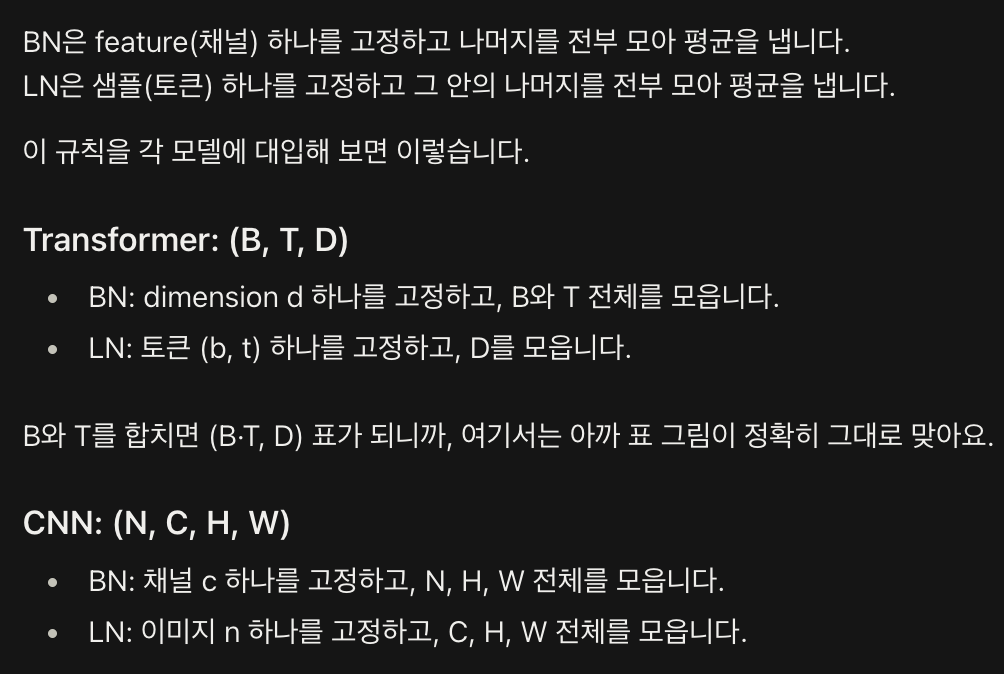

BN은 여러 sample들 사이, feature 고정

LN은 sample 고정. 여러 feature들 사이

# BN과 LN 코드 사용법

## 핵심 차이: 인자로 무엇을 넣나

|  | 인자 | 의미 |
| --- | --- | --- |
| BN | `num_features` = **C** (정수) | 남기는 축의 크기 |
| LN | `normalized_shape` = **평균내는 축들의 shape** | 뒤쪽 축들을 통째로 |
- BN은 "남기는 축(C)"을 적어요.
- LN은 "평균내는 축들의 shape"을 적어요. 반대입니다.

## BN

```python
import torch.nn as nn

nn.BatchNorm1d(C)   # 입력 (N, C) 또는 (N, C, L)
nn.BatchNorm2d(C)   # 입력 (N, C, H, W)
nn.BatchNorm3d(C)   # 입력 (N, C, D, H, W)
```

입력 차원 수에 맞는 버전(1d/2d/3d)을 고르고, 인자는 항상 **채널 수 C**입니다.

```python
bn = nn.BatchNorm2d(16)        # 채널이 16개
x = torch.randn(8, 16, 4, 4)
y = bn(x)                      # shape 그대로 (8, 16, 4, 4)
```

## LN

```python
nn.LayerNorm(normalized_shape)
```

입력의 **맨 뒤 축들과 shape이 일치**해야 해요.

```python
# Transformer: 입력 (N, T, D), 임베딩 D만 평균
ln = nn.LayerNorm(D)
x = torch.randn(8, 10, 512)
ln = nn.LayerNorm(512)
y = ln(x)                      # 토큰마다 512개로 평균

# CNN 스타일: 입력 (N, C, H, W), C,H,W 전부 평균
ln = nn.LayerNorm([16, 4, 4])
x = torch.randn(8, 16, 4, 4)
y = ln(x)                      # 샘플마다 16×4×4=256개로 평균
```

## 헷갈리는 포인트 (시험 함정)

**1. BN은 1d/2d/3d가 있고, LN은 하나뿐이에요.**
LN은 `normalized_shape`으로 축 개수를 직접 지정하기 때문에 `LayerNorm1d` 같은 건 없습니다.

**2. LN의 인자는 "뒤에서부터" 센다.**`(8, 16, 4, 4)`에서 다음처럼 동작해요.

| 코드 | 평균내는 축 | 남는 축 |
| --- | --- | --- |
| `LayerNorm(4)` | W | N, C, H |
| `LayerNorm([4, 4])` | H, W | N, C |
| `LayerNorm([16, 4, 4])` | C, H, W | N |

3번째 줄이 "샘플(N)을 남기고 나머지를 평균"하는 진짜 LN이에요.

**3. LN의 인자는 shape이 정확히 맞아야 해요.**`LayerNorm([16, 4, 4])`인데 입력이 `(8, 16, 5, 5)`이면 에러가 납니다. BN은 H, W가 달라도 상관없어요. LN은 H, W가 고정되어 있어야 하니, 이미지 크기가 가변이면 불편합니다.

**4. 학습 파라미터 shape이 다르다.**

|  | γ(weight), β(bias) shape |
| --- | --- |
| `BatchNorm2d(16)` | `(16,)` 채널마다 1개 |
| `LayerNorm([16,4,4])` | `(16, 4, 4)` 원소마다 1개 |
| `LayerNorm(512)` | `(512,)` |

## 모델 안에서 쓰는 모습

**CNN (BN)**

```python
nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1, bias=False),
    nn.BatchNorm2d(16),      # Conv의 out_ch와 같아야 함
    nn.ReLU(),
)
```

**Transformer 계열 (LN)**

```python
nn.Sequential(
    nn.Linear(512, 512),
    nn.LayerNorm(512),       # Linear의 out_features와 같아야 함
    nn.ReLU(),
)
```

두 경우 모두 **바로 앞 층의 출력 크기(out_ch / out_features)와 맞춰야** 합니다.

## 한눈에 정리

|  | BN | LN |
| --- | --- | --- |
| 클래스 | `BatchNorm1d/2d/3d` | `LayerNorm` (하나) |
| 인자 | C (정수) | 평균낼 뒤쪽 shape |
| 이미지 예 | `BatchNorm2d(C)` | `LayerNorm([C,H,W])` |
| Transformer 예 | 쓰지 않음 | `LayerNorm(D)` |
| 입력 크기 제약 | C만 맞으면 됨 | 지정한 shape이 정확히 맞아야 함 |
| running 통계 / train-eval 차이 | 있음 | 없음 |

## 직접 확인하기

노트북에서 다음을 돌려서 shape을 눈으로 확인해보세요.

```python
x = torch.randn(8, 16, 4, 4)

bn = nn.BatchNorm2d(16)
ln = nn.LayerNorm([16, 4, 4])

print(bn.weight.shape)   # torch.Size([16])
print(ln.weight.shape)   # torch.Size([16, 4, 4])

# LN은 샘플마다 평균이 0, BN은 채널마다 평균이 0
print(ln(x).mean(dim=(1, 2, 3)))   # 샘플별 평균 → 8개 값이 다 ≈ 0
print(bn(x).mean(dim=(0, 2, 3)))   # 채널별 평균 → 16개 값이 다 ≈ 0
```

두 출력 모두 0에 가깝게 나오는데, **어느 축으로 평균을 냈을 때 0이 되는지**가 다르다는 점을 확인하면 이 파트는 끝이에요.

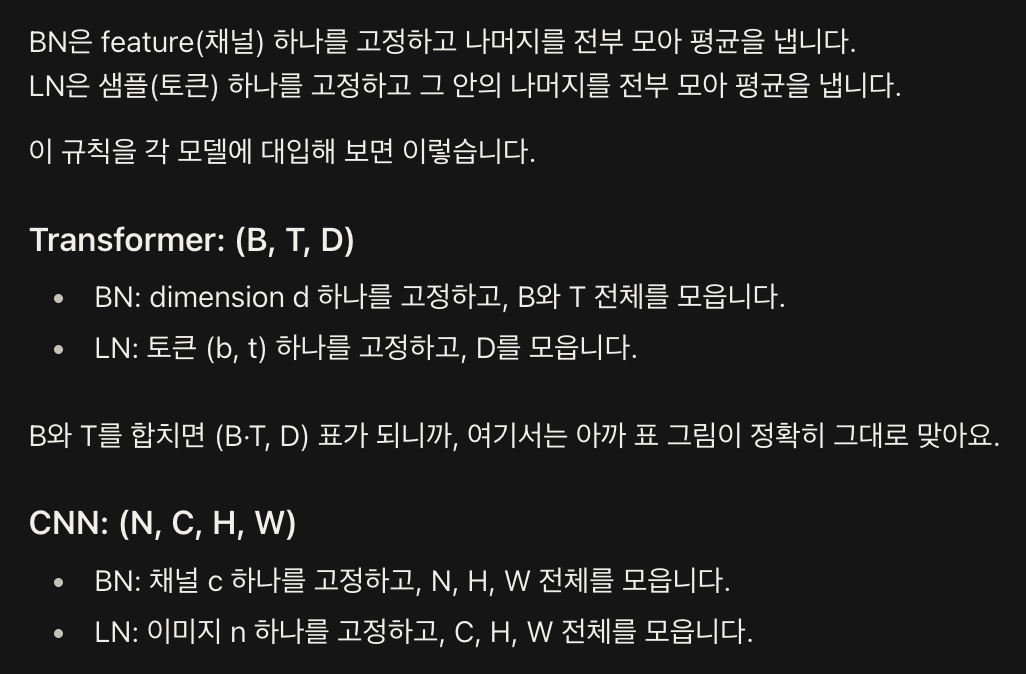


---

### A2. `nn.Identity()`

"입력을 그대로 돌려주는" 층이에요. 조건에 따라 층을 넣을지 말지 결정할 때 자리 채우기용으로 써요.

python

```python
self.shortcut = nn.Identity()out = self.shortcut(x)      # x 그대로 반환
```

### A3. 조건에 따라 attribute를 다르게 만들기

`__init__` 안에서 `if`로 어떤 층을 만들지 결정할 수 있어요.

python

```python
def __init__(self, use_dropout):    super().__init__()    if use_dropout:        self.drop = nn.Dropout(0.5)    else:        self.drop = nn.Identity()
```

두 경우 모두 `self.drop`이 존재하고 `nn.Module` 객체라서, `forward`에서 `self.drop(x)`를 똑같이 호출할 수 있어요.

### A4. 텐서 shape 조작 (Transformer 코드용)

Transformer 코드에는 shape 변환이 많이 나와요. **값이 아니라 배열의 모양만 바꾸는 함수**예요.

python

```python
x = torch.randn(2, 5, 8)          # (배치=2, 길이=5, 차원=8)

x.view(2, 5, 2, 4)                # 마지막 차원 8을 (2, 4)로 쪼갬 → (2, 5, 2, 4)
x.transpose(1, 2)                 # 1번 차원과 2번 차원을 맞바꿈
x.shape                           # torch.Size([2, 5, 8])
B, T, C = x.shape                 # 언패킹: B=2, T=5, C=8
x.size(-1)                        # 마지막 차원의 크기 = 8
```

**핵심은 "shape이 어떻게 바뀌는지 추적하는 것"** 이에요. 값 계산은 몰라도 돼요.

### A5. 행렬곱과 `softmax`

| 코드 | 뜻 |
| --- | --- |
| `a @ b` | 행렬곱 |
| `torch.softmax(x, dim=-1)` | 마지막 차원의 값들을 합이 1이 되는 확률로 변환 |
| `x.transpose(-2, -1)` | 마지막 두 차원을 맞바꿈 (행렬 전치) |

지금은 "attention은 `softmax(Q @ K.T) @ V` 형태"라고만 알아두세요. 수식을 이해할 필요는 없고, 코드가 **어떤 층을 만들고 어떻게 호출하는지**만 읽으면 돼요.

### A6. 잔차 연결(residual connection)

`x = x + f(x)`처럼 **입력을 출력에 더하는** 구조예요. 딥러닝 모델에서 매우 흔해요.

python

```python
x = x + self.layer(x)     # layer의 출력에 원래 입력 x를 더함
```

class 관점에서 특별한 건 없고, 그냥 **덧셈 연산**이에요. 원본 `x`가 살아 있어야 하니 `x = self.layer(x)`처럼 덮어쓰지 않고 더해요.

### A7. 읽는 요령: 이 순서로 읽으세요

새 모델 코드를 볼 때는 위에서부터 한 줄씩 읽지 말고 아래 순서로 읽으면 빨라요.

1. **`class X(nn.Module)`이 몇 개인지** 확인해요. (부품이 몇 종류인가)
2. **각 class의 `__init__`에서 `self.xxx = ...`를 모아서** 읽어요. (이 클래스가 어떤 부품을 갖고 있나)
3. **`forward`에서 그 부품을 어떤 순서로 호출하는지** 읽어요. (데이터가 어떻게 흐르나)
4. **부품 안에 부품이 있으면** 그 클래스로 넘어가요. (Step 5의 "점 이어서 타고 들어가기")

이 순서를 문제에서 계속 연습할 거예요.

---


Part B. 문제 (5문제)

문제를 전부 푼 다음 아래 풀이로 확인하세요. 설명이 요구된 문제는 설명까지 써주세요. 이번엔 실행 없이 코드를 눈으로 읽어서 푸는 문제예요.

Q1. ResNet BasicBlock 읽기
```python
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return self.relu(out)

(a) 이 클래스의 __init__이 만드는 attribute 이름을 전부 나열하세요. (self. 뒤에 붙는 이름들이에요.)
(b) forward에서 데이터가 흐르는 순서를 화살표(→)로 쓰세요. (예: x → conv1 → ...) shortcut은 어디서 합쳐지는지 표시하세요.
(c) BasicBlock(64, 64)와 BasicBlock(64, 128, stride=2)를 각각 만들었을 때 self.shortcut은 어떤 객체가 되나요? 그리고 왜 두 경우가 다른지 한 문장으로 쓰세요.
(d) if/else 두 분기 모두 self.shortcut을 만들어두는 덕분에, forward에서 무엇이 가능해지나요? (A3 참고)
```
conv1, bn1, conv2, bn2, relu, shortcut
x → conv1 → bn1 → relu → conv2 → bn2 ─┐
                                        (+) → relu → 출력
x → shortcut ──────────────────────────┘

| 호출 | `self.shortcut` |
| --- | --- |
| `BasicBlock(64, 64)` | `nn.Identity()` |
| `BasicBlock(64, 128, stride=2)` | `nn.Sequential(Conv2d(64, 128, 1, 2), BatchNorm2d(128))` |

forward에서 if 없이 self.shortcut(x) 한 줄로 똑같이 호출

### Q2. 경로 읽기 (객체 안의 객체)

Q1의 `BasicBlock`을 이용한 아래 모델이 있어요.

python

```python
class TinyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Conv2d(3, 16, 3, 1, 1)
        self.layer1 = nn.Sequential(
            BasicBlock(16, 16),
            BasicBlock(16, 32, stride=2),
        )
        self.head = nn.Linear(32, 10)

model = TinyResNet()
```

아래 각 표현이 **무슨 타입의 객체(또는 값)** 인지, 그리고 **값이라면 얼마인지** 쓰세요.

| ① | `model.stem` | nn.Conv2d(3, 16, 3, 1, 1) |
| --- | --- | --- |
| ② | `model.layer1` | nn.Sequential |
| ③ | `model.layer1[1]` | BasicBlock(16, 32, stride=2) |
| ④ | `model.layer1[1].conv1.in_channels` | 16 |
| ⑤ | `model.layer1[1].shortcut` | nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=2),
                nn.BatchNorm2d(out_ch),
            ) |
| ⑥ | `model.head.out_features` | 10 |

(hint: `nn.Conv2d`는 `in_channels`, `out_channels`를 attribute로 저장해요. `nn.Sequential`은 `ModuleList`처럼 `[인덱스]`로 꺼낼 수 있어요.)
```

Q3. MultiHeadAttention의 __init__ / forward 읽기
```python
class MultiHeadAttention(nn.Module):
    def __init__(self, dim, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        att = torch.softmax(att, dim=-1)
        out = (att @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out)

```

dim=8, n_heads=2로 mha = MultiHeadAttention(8, 2)를 만들고, 입력 x의 shape이 (2, 5, 8)이라고 해요.

(a) mha.head_dim의 값과, mha.qkv가 어떤 nn.Linear(?, ?)인지 쓰세요. 
4, nn.Linear(8,8)
(b) forward의 q(처음 chunk 직후)와 .view(...).transpose(1, 2)를 거친 뒤의 shape을 각각 쓰세요. (B=2, T=5, C=8)
(2,5,8) -> (2,5,24) -> (2,5,8)
(2,5,8) -> (2,5,2,4) -> (2,2,5,4)

(c) mha(x)의 출력 shape을 쓰세요.
입력 x와 같다.

(d) 이 클래스에서 nn.Module 객체인 attribute는 몇 개이고, 일반 숫자(int) attribute는 몇 개인가요? 각각 이름을 쓰세요.
nn.Module 객체 attribute: 2개 → qkv, proj
일반 int attribute: 2개 → n_heads, head_dim
